## 1. 解释深度学习神经元运算的原理

In [ ]:
"""
深度学习中的神经元（Neural Unit）是人工神经网络的基本组成单元。每个神经元的运算过程通常包含以下几个核心步骤：

1. 输入加权求和：
   神经元会接收来自上一层的输入，每个输入 \( x_i \) 都对应一个可学习的权重 \( w_i \)。神经元会对这些输入与权重逐一相乘后求和，并加上一个可学习的偏置项 \( b \)，其数学表达式为：
   
   \[
   z = \sum_{i=1}^n w_i x_i + b
   \]

2. 非线性激活：
   神经元通过激活函数（如sigmoid、ReLU、tanh等）对上述加权和 \( z \) 进行非线性变换，赋予网络表达复杂函数的能力。计算公式为：

   \[
   a = f(z)
   \]

   其中 \( f \) 为激活函数。例如，ReLU激活为 \( f(z) = \max(0, z) \)，Sigmoid为 \( f(z) = \frac{1}{1 + e^{-z}} \)。

整个神经元的前向传播过程可以用以下伪代码表示：

```python
import torch
import torch.nn as nn

# 定义一个简单的神经元（全连接层）示例
linear = nn.Linear(in_features=3, out_features=1)
activation = nn.ReLU()

# 输入向量
x = torch.tensor([[0.5, -1.2, 3.3]])

# 线性加权和 + 激活
z = linear(x)         # 相当于 w1*x1 + w2*x2 + w3*x3 + b
a = activation(z)     # 非线性激活
print(a)
```

简而言之，神经元的本质就是“加权求和——加上偏置——非线性变换”这一系列运算。通过多层神经元的叠加和参数的学习，使得深度学习模型具备了强大的特征表达和模式识别能力。
"""


## 2. 默写softmax, 交叉熵公式 

In [1]:
import torch
import torch.nn.functional as F

# softmax公式
def softmax(x):
    """
    计算softmax:
    softmax(x_i) = exp(x_i) / sum_j(exp(x_j))
    """
    exps = torch.exp(x)
    return exps / torch.sum(exps, dim=-1, keepdim=True)

# 交叉熵公式
def cross_entropy(y_pred, y_true):
    """
    计算交叉熵:
    CrossEntropy(y, t) = -sum_i t_i * log(y_i)
    其中y_pred应为softmax后的概率，y_true为one-hot标签
    """
    return -torch.sum(y_true * torch.log(y_pred + 1e-8), dim=-1).mean()

# 示例
logits = torch.tensor([[2.0, 1.0, 0.1]])
y_true = torch.tensor([[1, 0, 0]], dtype=torch.float)

probs = softmax(logits)
loss = cross_entropy(probs, y_true)
print("Softmax结果：", probs)
print("交叉熵损失：", loss)


Softmax结果： tensor([[0.6590, 0.2424, 0.0986]])
交叉熵损失： tensor(0.4170)


## 3.实战FashionMNIST分类

In [2]:
# 导入必要的库
import matplotlib as mpl  # matplotlib主模块，用于设置全局绘图参数等
import matplotlib.pyplot as plt  # pyplot模块，常用作绘制图表
# 在Jupyter notebook中内联显示图表（每次运行都会在单元格中显示图片而不是弹出新窗口）
%matplotlib inline  

import numpy as np  # 数学运算库，提供高效的数组操作
import sklearn  # 机器学习工具包，包含数据预处理、分类、回归等大量方法
import pandas as pd  # 数据分析与处理库，用于表格、数据读写
import os  # 操作系统接口，用于路径、目录等操作
import sys  # 提供对解释器使用环境的访问
import time  # 处理时间和计时相关操作
from tqdm.auto import tqdm  # 进度条库，tqdm.auto能自动适配notebook和终端环境

import torch  # PyTorch主库，用于深度学习建模、张量计算等
import torch.nn as nn  # PyTorch中神经网络相关层和模块
import torch.nn.functional as F  # PyTorch中常用的函数式操作，比如激活函数、损失函数等

# 打印当前Python解释器的版本信息，方便环境调试与复现
print(sys.version_info)

# 打印上述主要包的名称及其版本信息，方便确认各个包的安装及版本（便于代码复现）
for module in mpl, np, pd, sklearn, torch:
    print(module.__name__, module.__version__)
    
# 设置运行设备:
# 若检测到可用的GPU(cuda:0)，则使用GPU加速；
# 否则回退为CPU运行（适用于无GPU机器）。
device = torch.device("cuda:0") if torch.cuda.is_available() else torch.device("cpu")
print(device)  # 输出当前使用的设备信息


sys.version_info(major=3, minor=12, micro=3, releaselevel='final', serial=0)
matplotlib 3.10.8
numpy 2.4.0
pandas 2.3.3
sklearn 1.8.0
torch 2.9.1+cpu
cpu


In [18]:
from torchvision import datasets                # 导入torchvision中的数据集模块，用于加载各种内置数据集
from torchvision.transforms import ToTensor     # 导入ToTensor转换，用于将PIL图像转换为Tensor（本例暂未用）
from torchvision import transforms              # 导入transforms模块，可以进行一系列数据预处理（本例暂未用）
from typing import Any                          # 导入Any类型，用于类型注解（本处可选）

def get_fashion_mnist_datasets() -> tuple[datasets.FashionMNIST, datasets.FashionMNIST]:
    """
    加载FashionMNIST的训练集和测试集，并返回它们。
    :return: (train_ds, test_ds)
    """
    train_ds: datasets.FashionMNIST = datasets.FashionMNIST(
        root="./chapter2/data/",      # 数据存放的路径，将数据下载到该文件夹下
        train=True,                   # 指定为训练集
        download=True,                # 如果本地没有数据，则自动下载
        transform=None                # 这里不对原始图片做任何transform（即图片为PIL.Image格式）
    )

    test_ds: datasets.FashionMNIST = datasets.FashionMNIST(
        root="./chapter2/data/",      # 同样的数据根目录
        train=False,                  # 指定为测试集
        download=True,                # 自动下载（如果尚未下载）
        transform=None                # 不做transform，保留原本图片
    )
    return train_ds, test_ds          # 返回训练集和测试集对象

train_ds, test_ds = get_fashion_mnist_datasets()  # 调用上面的函数，获取数据集对象

# 输出关键数据信息，便于了解数据集基本情况
print(f"训练集样本数: {len(train_ds)}")    # 打印训练集样本数量
print(f"测试集样本数: {len(test_ds)}")    # 打印测试集样本数量

# 获取类别信息，如果属性存在的话
classes = train_ds.classes if hasattr(train_ds, "classes") else None
print(f"类别数: {len(classes) if classes else '未知'}")   # 打印类别数量
if classes:
    print(f"类别标签: {classes}")                         # 打印类别名字列表

# 从训练集中取出一条样本（图像及其标签），并输出其相关信息
sample_img, sample_label = train_ds[0]  # 获取索引为0的样本（PIL图像和对应标签）

# 输出样本图片的尺寸（size），注意PIL图像有size属性（宽, 高）
print(f"单张图片尺寸: {sample_img.size if hasattr(sample_img, 'size') else '未知'}")
# 输出样本图片的类型，应为 PIL.Image.Image
print(f"单张图片类型: {type(sample_img)}")
# 输出样本图片的标签（整数，0~9）
print(f"单张图片label: {sample_label}")


训练集样本数: 60000
测试集样本数: 10000
类别数: 10
类别标签: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
单张图片尺寸: (28, 28)
单张图片类型: <class 'PIL.Image.Image'>
单张图片label: 9


In [24]:
img, label = train_ds[0]
print(type(img))
print(type(train_ds))
print(train_ds[0])

<class 'PIL.Image.Image'>
<class 'torchvision.datasets.mnist.FashionMNIST'>
(<PIL.Image.Image image mode=L size=28x28 at 0x1894369AD20>, 9)


In [29]:
# 显示图片内容信息的函数，这里要求不对img进行 transforms.ToTensor() 或归一化等操作
def show_img_content(img):
    """
    打印PIL图像的尺寸、模式，并在为灰度图像模式时，输出像素值列表。
    :param img: 传入的PIL.Image对象
    :return: 若为灰度图'L'模式则返回像素值列表，否则返回None
    """
    from PIL import Image

    # 检查输入类型是否为PIL.Image.Image
    # 如果不是，可能需要用Image.open加载（根据具体数据类型决定）
    # 这里已假定传入的是PIL Image对象，所以不重复加载

    print("图像大小:", img.size)  # 输出图像的尺寸，例如(28, 28)
    print("图像模式:", img.mode)  # 输出图像模式，如'L'表示8位灰度图

    # 如果图像是单通道灰度图（mode='L'），获取所有像素值组成的列表
    if img.mode == 'L':
        pixel_values = list(img.getdata())
        print(pixel_values)
     #   return pixel_values  # 返回像素值列表
    # 如果不是灰度图，则不返回像素列表
    return None  # 若不是'L'模式，则返回None

show_img_content(img) # 调用函数显示内容。注意只有img为PIL图片且未转为Tensor时才能正确显示

图像大小: (28, 28)
图像模式: L
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 13, 73, 0, 0, 1, 4, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0, 36, 136, 127, 62, 54, 0, 0, 0, 1, 3, 4, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 6, 0, 102, 204, 176, 134, 144, 123, 23, 0, 0, 0, 0, 12, 10, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 155, 236, 207, 178, 107, 156, 161, 109, 64, 23, 77, 130, 72, 15, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141, 88, 172, 66, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196, 229, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245, 173, 0, 0, 0, 

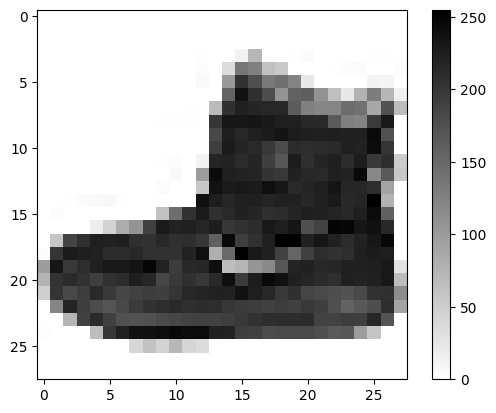

In [31]:
# 注意：本段代码必须保证上方未对img应用 transforms.ToTensor()，否则无法正常imshow显示。
# 原因：transforms.ToTensor() 会将PIL图像对象转换为torch.Tensor类型，且格式通常为[C, H, W]（通道数在前），
# 而plt.imshow期待输入为形如[H, W]或[H, W, 3/4]的numpy数组或PIL图片，且若为Tensor需处理格式，灰度图还需去掉通道维。
# 如果对img做过ToTensor()，直接传进去会报错或者显示异常，因此需要保持img为原始的PIL Image类型。

def show_single_image(img_arr):
    """
    显示单张图片（灰度图）。
    参数说明：
        img_arr: 期望为PIL.Image对象（如不经过transforms.ToTensor处理的原始图片），
                 若为Tensor类型，需先转换为numpy数组并调整形状。
    """
    # 使用matplotlib展示图像。cmap="binary"表示采用黑白色阶（适合灰度图）。
    plt.imshow(img_arr, cmap="binary") # 显示图片
    plt.colorbar()                     # 显示颜色条
    plt.show()                        # 弹出窗口

# 由于上方img未做ToTensor，因此此处传入的是PIL图像，可以直接显示。
show_single_image(img)

In [41]:
# 加载FashionMNIST数据集并进行详细注释

# 导入torchvision中的datasets与transforms模块
from torchvision import datasets, transforms

# 定义图像数据的预处理步骤。
# transforms.Compose可以将多个处理步骤组合到一起，按顺序依次执行。
transform = transforms.Compose([
    # 将输入的PIL图像或NumPy ndarray转换为torch.FloatTensor，并将像素值归一化到[0, 1]之间
    transforms.ToTensor(),
    # 如果需要进行进一步标准化，可取消下方的注释：
    transforms.Normalize((0.5,), (0.5,))  # 将数据归一化到[-1, 1]，更适用于部分深度学习模型
])

# 下载并加载FashionMNIST训练集
train_dataset = datasets.FashionMNIST(
    root='./chapter2/data',    # 数据集存储目录，如果目录下没有数据会自动下载
    train=True,                # 加载训练集数据（设为False时加载测试集）
    download=True,             # 数据不存在时自动下载
    transform=transform        # 指定预处理方法，上面定义的transform
)

# 下载并加载FashionMNIST测试集
test_dataset = datasets.FashionMNIST(
    root='./chapter2/data',    # 数据存储目录，建议训练集和测试集用同一目录
    train=False,               # 加载测试集数据
    download=True,             # 不存在时自动下载到指定目录
    transform=transform        # 使用相同的数据预处理方法
)

# 打印训练集和测试集的相关基本信息
print(f"训练集大小: {len(train_dataset)}")   # 训练集中图片的数量（例如60000）
print(f"测试集大小: {len(test_dataset)}")   # 测试集中图片的数量（例如10000）
print(f"训练集数据类型: {type(train_dataset)}") # 数据集对象的类型（torchvision.datasets.FashionMNIST）
print(f"标签的数据类型: {type(train_dataset[0][1])}")  # 显示标签的类型


# 打印单个数据集元素类型和内容，便于了解数据结构
print(f"单个dataset元素类型: {type(train_dataset[0])}")  # 返回(tuple)，一般为(图像Tensor, 标签)
print(f"单个dataset元素是什么: {train_dataset[0]}")      # 实际查看第一个样本的内容（包含Tensor和int型label）

# 打印图像的形状信息。train_dataset[0][0]是第一个样本的图像内容（Tensor）。
print(f"图像尺寸: {train_dataset[0][0].shape}")         # 输出为torch.Size([1, 28, 28])，表示通道数、高、宽

# FashionMNIST数据集的标签类别信息（10类），可在官方仓库https://github.com/zalandoresearch/fashion-mnist查看详细说明
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"类别数量: {len(class_names)}")   # 类别总数：10
print(f"类别标签: {class_names}")        # 打印所有类别名称


训练集大小: 60000
测试集大小: 10000
训练集数据类型: <class 'torchvision.datasets.mnist.FashionMNIST'>
标签的数据类型: <class 'int'>
单个dataset元素类型: <class 'tuple'>
单个dataset元素是什么: (tensor([[[-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000],
         [-1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000, -1.0000,
          -1.0000, -1.0000, -1.0000, -1

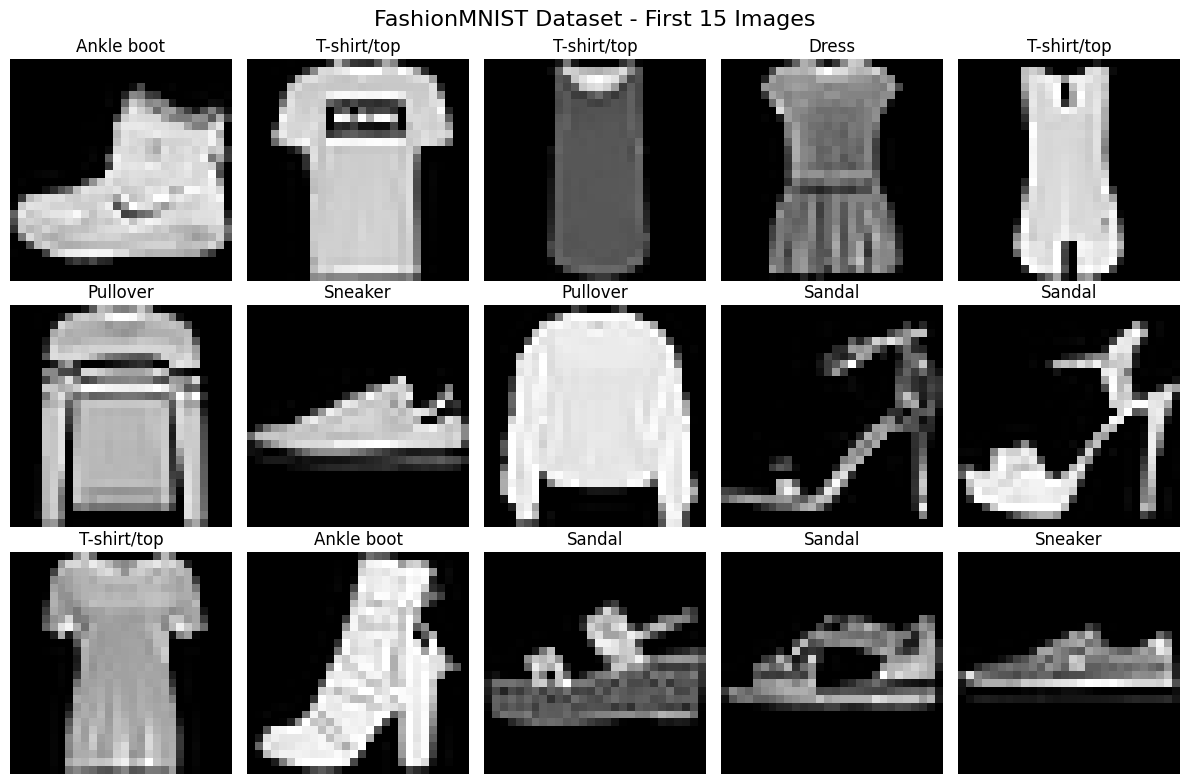

In [38]:
import matplotlib.pyplot as plt  # 导入用于绘图的Matplotlib库

# 创建一个3行5列的子图画布，figsize设定整体尺寸为12x8英寸
fig, axes = plt.subplots(3, 5, figsize=(12, 8))
# 设置整个大图的标题，字号为16
fig.suptitle('FashionMNIST Dataset - First 15 Images', fontsize=16)

# 遍历前15个训练集样本
for i in range(15):
    row = i // 5  # 计算当前样本应放在画布的哪一行（每行5个）
    col = i % 5   # 计算当前样本应放在画布的哪一列

    # 从train_dataset中获取第i个样本的图像数据和标签
    image, label = train_dataset[i]
    
    # 去除channel维度(灰度图只需一个通道)，将torch tensor转为numpy数组用于绘图
    image_np = image.squeeze().numpy()

    # 在对应的子图位置绘制当前图片，灰度显示（cmap='gray'）
    axes[row, col].imshow(image_np, cmap='gray')
    # 设置子图标题为类别名称（通过class_names列表查找标签名）
    axes[row, col].set_title(f'{class_names[label]}')
    # 不显示子图的坐标轴刻度
    axes[row, col].axis('off')

# 调整子图之间的间距，使标题和图片不重叠
plt.tight_layout()
# 显示画布（所有子图一起输出）
plt.show()


In [40]:
from torch.utils.data import DataLoader  # 导入PyTorch中用于批量加载数据的工具

# 定义每个批次包含的样本数量，batch_size越大，每次传给网络的数据越多
batch_size = 32

# 构建训练集的DataLoader
# DataLoader可自动实现分批、打乱数据等操作，提高训练效率
train_loader = DataLoader(
    train_dataset,           # 训练集数据
    batch_size=batch_size,   # 每个batch的样本数
    shuffle=True,            # 是否在每个epoch开始前打乱数据（有助于提升训练效果）
    num_workers=2            # 用几个子进程来加载数据，0表示只用主进程
)

# 构建测试集的DataLoader
# 测试集通常不需要打乱顺序
test_loader = DataLoader(
    test_dataset,            # 测试集/验证集数据
    batch_size=batch_size,   # 每个batch的样本数
    shuffle=False,           # 测试时不打乱顺序，保证评估一致性
    num_workers=2            # 用2个子进程加载数据，加快速度
)

# 打印训练集和测试集各自被分成的批次数（len(DataLoader)返回总batch数）
print(f"训练集DataLoader批次数: {len(train_loader)}")   
print(f"测试集DataLoader批次数: {len(test_loader)}")
print(f"每个批次大小: {batch_size}")

# 查看一个训练集批次的数据样例
# 创建训练集DataLoader的迭代器
train_iter = iter(train_loader)
# 取出第一个批次: 返回批次的图像数据(batch_images)与对应标签(batch_labels)
batch_images, batch_labels = next(train_iter)
# 打印当前批次图像的Tensor形状: 一般为[batch_size, 通道数, 高, 宽]
print(f"批次图像张量形状: {batch_images.shape}")
# 打印当前批次标签的Tensor形状: 一般为[batch_size]
print(f"批次标签张量形状: {batch_labels.shape}")
# 打印该批次所有标签（即每个样本的类别编号）
print(batch_labels)

训练集DataLoader批次数: 1875
测试集DataLoader批次数: 313
每个批次大小: 32
批次图像张量形状: torch.Size([32, 1, 28, 28])
批次标签张量形状: torch.Size([32])
tensor([6, 8, 0, 9, 8, 6, 7, 8, 3, 4, 6, 7, 2, 7, 9, 1, 1, 0, 4, 1, 4, 4, 2, 8,
        5, 6, 2, 9, 4, 8, 1, 4])


In [ ]:
import torch.nn as nn

# 定义一个具有两层全连接隐藏层的神经网络
class TwoLayerNN(nn.Module):
    def __init__(self):
        # 调用父类nn.Module的构造函数，初始化神经网络所需的基础结构
        super(TwoLayerNN, self).__init__()
        # 展平成一维向量（例如28*28的图像 -> 784维向量）
        self.flatten = nn.Flatten() 
        
        # 第一层全连接：将784维输入变为300维
        self.fc1 = nn.Linear(28*28, 300) 
        
        # 第一层激活函数，ReLU可以增加网络的非线性能力
        self.relu1 = nn.ReLU() 
        
        # 第二层全连接：将300维输入变为100维
        self.fc2 = nn.Linear(300, 100) 
        
        # 第二层激活函数
        self.relu2 = nn.ReLU() 
        
        # 第三层全连接：将100维输入变为10维（对应10个类别）
        self.fc3 = nn.Linear(100, 10) 
        
    def forward(self, x):
        # 前向传播依次经过各层，同时打印中间张量的形状，方便调试
        x = self.flatten(x)
        print(f"After Flatten: {x.shape}")  # 应为 [batch_size, 784]
        
        x = self.fc1(x)
        print(f"After fc1: {x.shape}")      # 应为 [batch_size, 300]
        
        x = self.relu1(x)
        print(f"After relu1: {x.shape}")    # 应为 [batch_size, 300]
        
        x = self.fc2(x)
        print(f"After fc2: {x.shape}")      # 应为 [batch_size, 100]
        
        x = self.relu2(x)
        print(f"After relu2: {x.shape}")    # 应为 [batch_size, 100]
        
        x = self.fc3(x)
        print(f"After fc3: {x.shape}")      # 应为 [batch_size, 10]
        
        return x

# 创建模型实例
model = TwoLayerNN()
# 打印模型结构以确认网络层次
print(model)


TwoLayerNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [46]:
# 使用随机输入对模型进行一次前向计算以验证模型结构是否正确

import torch  # 导入torch库，PyTorch的基础包

# 生成一个随机的输入张量，模拟一批(batch)数据
# 这里batch_size=32，表示32个样本，每个样本为1通道28x28的图像（如MNIST数据格式）
dummy_input = torch.randn(32, 1, 28, 28)  

# 将dummy_input输入模型，进行前向传播/前向计算/正向传播
# 这一步会依次通过模型定义的所有网络层，并输出结果
output = model(dummy_input) 

# 打印模型输出的形状
# 输出应为[32, 10]，即32个样本每个有10个类别的评分（未经softmax处理）
print(f"Output shape: {output.shape}")  


After Flatten: torch.Size([32, 784])
After fc1: torch.Size([32, 300])
After relu1: torch.Size([32, 300])
After fc2: torch.Size([32, 100])
After relu2: torch.Size([32, 100])
After fc3: torch.Size([32, 10])
Output shape: torch.Size([32, 10])


In [47]:
# 输出 model 每一层的参数量，并添加详细注释说明各步骤

total_params = 0  # 初始化用于累计模型所有参数的总数

print("各层参数量统计：")  # 输出表头，说明接下来为各层参数统计信息

# 遍历模型中所有需要优化的参数。named_parameters()返回（参数名,参数值）元组
for name, param in model.named_parameters():  
    # 只统计那些需要梯度更新（即反向传播中会被优化）的参数
    if param.requires_grad:  
        num_params = param.numel()  # param.numel() 返回该参数张量的元素总数，即参数数量
        total_params += num_params  # 将当前参数数量累加到总参数量
        # 打印当前参数名和该参数的数量，帮助定位每一层的参数规模
        print(f"{name}: {num_params}")  

# 最后输出所有层累计后的参数总数，反映整个模型的复杂度
print(f"模型总参数量: {total_params}")  


各层参数量统计：
fc1.weight: 235200
fc1.bias: 300
fc2.weight: 30000
fc2.bias: 100
fc3.weight: 1000
fc3.bias: 10
模型总参数量: 266610


In [49]:
import torch.nn as nn

class TwoLayerNN(nn.Module):
    def __init__(self):
        super(TwoLayerNN, self).__init__()
        # 定义网络层
        # nn.Flatten将输入的多维张量（如[batch_size,1,28,28]）展平成一维（如[batch_size,784]）
        self.flatten = nn.Flatten()  # 展平操作，将28*28的二维图像转换为784维的向量，便于后续全连接层处理

        # 第一个全连接层: 输入784维（28*28），输出300维
        self.fc1 = nn.Linear(28*28, 300)  # 从784维输入到300维隐层

        # 第一层激活函数: ReLU（Rectified Linear Unit）
        self.relu1 = nn.ReLU()  # 在第一个全连接层后进行非线性变换，提高网络表达力

        # 第二个全连接层: 输入300维，输出100维
        self.fc2 = nn.Linear(300, 100)   # 从300维隐层到100维隐层

        # 第二层激活函数: ReLU
        self.relu2 = nn.ReLU()  # 在第二个全连接层后进行非线性变换

        # 第三个全连接层: 输入100维，输出10维（类别数，例如MNIST有10类）
        self.fc3 = nn.Linear(100, 10)    # 输出层，得到最终类别的分数（未做概率归一化）

    def forward(self, x):
        # 前向传播过程：定义数据如何经过各层
        x = self.flatten(x)      # (batch_size, 1, 28, 28) -> (batch_size, 784)

        x = self.fc1(x)          # (batch_size, 784) -> (batch_size, 300)
        x = self.relu1(x)        # (batch_size, 300) -> (batch_size, 300), 引入非线性

        x = self.fc2(x)          # (batch_size, 300) -> (batch_size, 100)
        x = self.relu2(x)        # (batch_size, 100) -> (batch_size, 100), 再次引入非线性

        x = self.fc3(x)          # (batch_size, 100) -> (batch_size, 10)，输出对每一类的预测得分

        return x                 # 返回最终的输出（未经过softmax）

# 实例化模型对象，调用__init__方法初始化网络结构
model = TwoLayerNN()

# 打印模型结构，展示每一层的详细信息，便于检查网络搭建是否正确
print(model)


TwoLayerNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


In [53]:
import torch.nn as nn      # 导入PyTorch中的神经网络模块，包含常用的层、损失函数等
import torch.optim as optim   # 导入PyTorch中的优化器模块，包含各种优化算法

# 定义损失函数：使用交叉熵损失（适用于多分类任务）
# nn.CrossEntropyLoss()会自动将模型的原始输出(logits)和真实标签进行比对
# 内部已经包含了softmax操作，将输出转换为概率分布并计算损失
# 如果你的目标是分类问题且未对输出做softmax，这个损失函数最方便
criterion = nn.CrossEntropyLoss()

# 定义优化器：使用随机梯度下降（SGD）算法来优化模型参数
# optimizer负责根据损失函数对模型的参数（如权重weight和偏置bias）进行更新
# model.parameters()会将模型中所有可学习的参数传递给优化器
# lr=0.001指定了学习率，即每次参数更新幅度，学习率通常需要调优
# 这里使用的是SGD优化器。如果要换成Adam，只需将optim.SGD改为optim.Adam
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [54]:
# 导入自定义训练脚本，其中包含Trainer类用于模型训练流程的封装
import chapter2.wangdao_train as wangdao_train

# 实例化Trainer训练器，方便管理训练和验证过程
# 参数说明:
#   model          —— 要训练的神经网络模型
#   train_loader   —— 训练集的DataLoader，用于批量加载训练数据
#   val_loader     —— 验证/测试集的DataLoader，这里用test_loader作为验证集
#   criterion      —— 损失函数，用于计算训练和验证的损失（如交叉熵损失）
#   optimizer      —— 优化器，负责根据损失调整模型参数（如Adam）
#   device         —— 设备类型（"cpu"或"cuda"），决定模型和数据运算的位置
trainer = wangdao_train.Trainer(
    model=model,
    train_loader=train_loader,    # 训练数据加载器
    val_loader=test_loader,       # 测试数据加载器，此处用作验证集
    criterion=criterion,          # 损失函数
    optimizer=optimizer,          # 优化器
    device=device                 # 设备（"cpu"或"cuda"）
)

# 设置训练轮数（epoch数）：指定整个训练集将在神经网络前向与反向传播过程中遍历的次数
num_epochs = 10  # 可根据任务复杂度调整

# 启动训练：循环num_epochs次，自动执行训练与验证流程
trainer.train(num_epochs)


[Step 100] Val Loss: 0.6438 Val Acc: 0.7685
[Step 200] Val Loss: 0.5411 Val Acc: 0.8016
[Step 300] Val Loss: 0.5202 Val Acc: 0.8081
[Step 400] Val Loss: 0.5042 Val Acc: 0.8143
[Step 500] Val Loss: 0.5116 Val Acc: 0.8128
[Step 600] Val Loss: 0.4713 Val Acc: 0.8289
[Step 700] Val Loss: 0.5214 Val Acc: 0.8098
[Step 800] Val Loss: 0.5008 Val Acc: 0.8166
[Step 900] Val Loss: 0.5008 Val Acc: 0.8226
[Step 1000] Val Loss: 0.4555 Val Acc: 0.8379
[Step 1100] Val Loss: 0.4587 Val Acc: 0.8379
[Step 1200] Val Loss: 0.4393 Val Acc: 0.8422
[Step 1300] Val Loss: 0.4434 Val Acc: 0.8427
[Step 1400] Val Loss: 0.4690 Val Acc: 0.8248
[Step 1500] Val Loss: 0.4573 Val Acc: 0.8320
[Step 1600] Val Loss: 0.4370 Val Acc: 0.8411
[Step 1700] Val Loss: 0.4348 Val Acc: 0.8414
[Step 1800] Val Loss: 0.4384 Val Acc: 0.8379
Epoch [1/20]  Train Loss: 0.4785  Train Acc: 0.8243
[Step 1900] Val Loss: 0.4316 Val Acc: 0.8413
[Step 2000] Val Loss: 0.4191 Val Acc: 0.8477
[Step 2100] Val Loss: 0.4263 Val Acc: 0.8423
[Step 2200] 

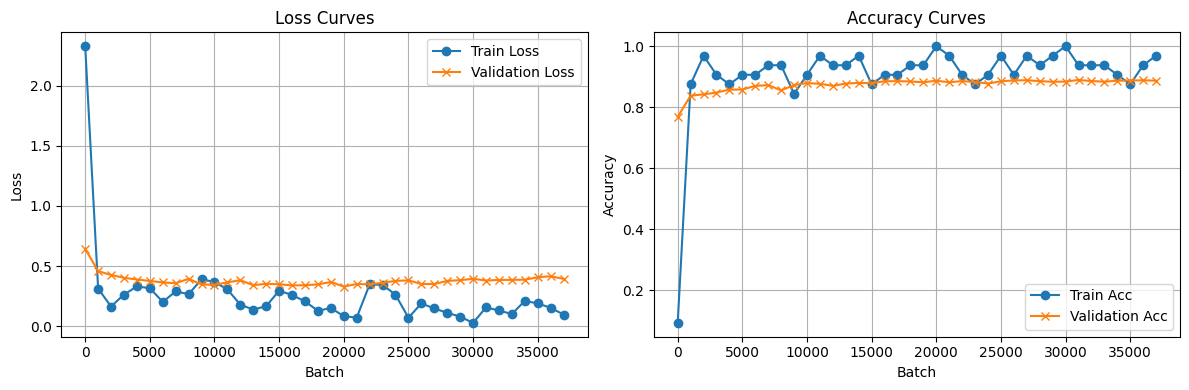

In [ ]:
# 绘制训练和验证过程中的损失曲线和准确率曲线，帮助分析模型的训练效果与泛化能力
trainer.plot_curves()

   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/5.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/5.5 MB ? eta -:--:--
   --- ------------------------------------ 0.5/5.5 MB 1.5 MB/s eta 0:00:04
   ----- ---------------------------------- 0.8/5.5 MB 1.4 MB/s eta 0:00:04
   ------- -------------------------------- 1.0/5.5 MB 1.3 MB/s eta 0:00:04
   ------- -------------------------------- 1.0/5.5 MB 1.3 MB/s eta 0:00:04
   --------- ------------------------------ 1.3/5.5 MB 1.2 MB/s eta 0:00:04
   ----------- ---------------------------- 1.6/5.5 MB 1.1 MB/s eta 0:00:04
   ------------- -------------------------- 1.8/5.5 MB 1.2 MB/s eta 0:00:04
   --------------- ------------------------ 2.1/5.5 MB 1.2 MB/s eta 0:00:03
   ------------------ --------------------- 2.6/5.5 MB 1.2 MB/s eta 0:00:03
   -------------------- ----------------